# GF-Gini vs GDP Regression — Sector-Level Biodiversity Loss Footprint (2023)

This notebook computes GF-Gini inequality coefficients (Li et al. 2024, *Nature Climate Change*, eq. 7) for four biodiversity loss footprint categories — Total, Agriculture, Livestock, and Forestry — across 164 countries, then regresses these against per-capita GDP (PPP, 2023 USD). Footprint data are derived from the GLORIA MRIO model; the unit is **PDF** (Potentially Disappeared Fraction). Results are exported as two CSV files and a publication-ready 2×2 logarithmic regression figure formatted to Nature sub-journal standards (180 mm × 160 mm, 300 dpi).

[S1] Configuration complete.
[S2] footprint_income_long_2023.csv loaded: 163 countries, 25436 valid (Population>0) rows.
4class sector counts (read from sector_class.xlsx):
  Agriculture: 9 sectors
  Forestry: 1 sectors
  Livestock: 5 sectors
  Others: 105 sectors
[S3] Sector classification done. Categories: ['Agriculture', 'Forestry', 'Livestock', 'Others']
Loaded GDP from cache: 241 records.
[S4] GDP source: local cache: E:\phdstudy\reference\WB_GDP_PPP_2023.csv
     Countries with valid GDP: 152 / 164
[S5] GF-Gini computation complete.
     Total         : 160 valid countries
     Agriculture   : 160 valid countries
     Livestock     : 160 valid countries
     Forestry      : 160 valid countries
     Saved → E:\phdstudy\BiodiversityPHD-2ndpaper\BiodiversityPHD-2ndpaper\results\gini_gdp_regression\gini_by_country_2023.csv
[S6] Total         : n=151, r=-0.573, R²=0.328, p < 0.001, slope=-0.0554
[S6] Agriculture   : n=151, r=-0.602, R²=0.363, p < 0.001, slope=-0.0597
[S6] Livestock   

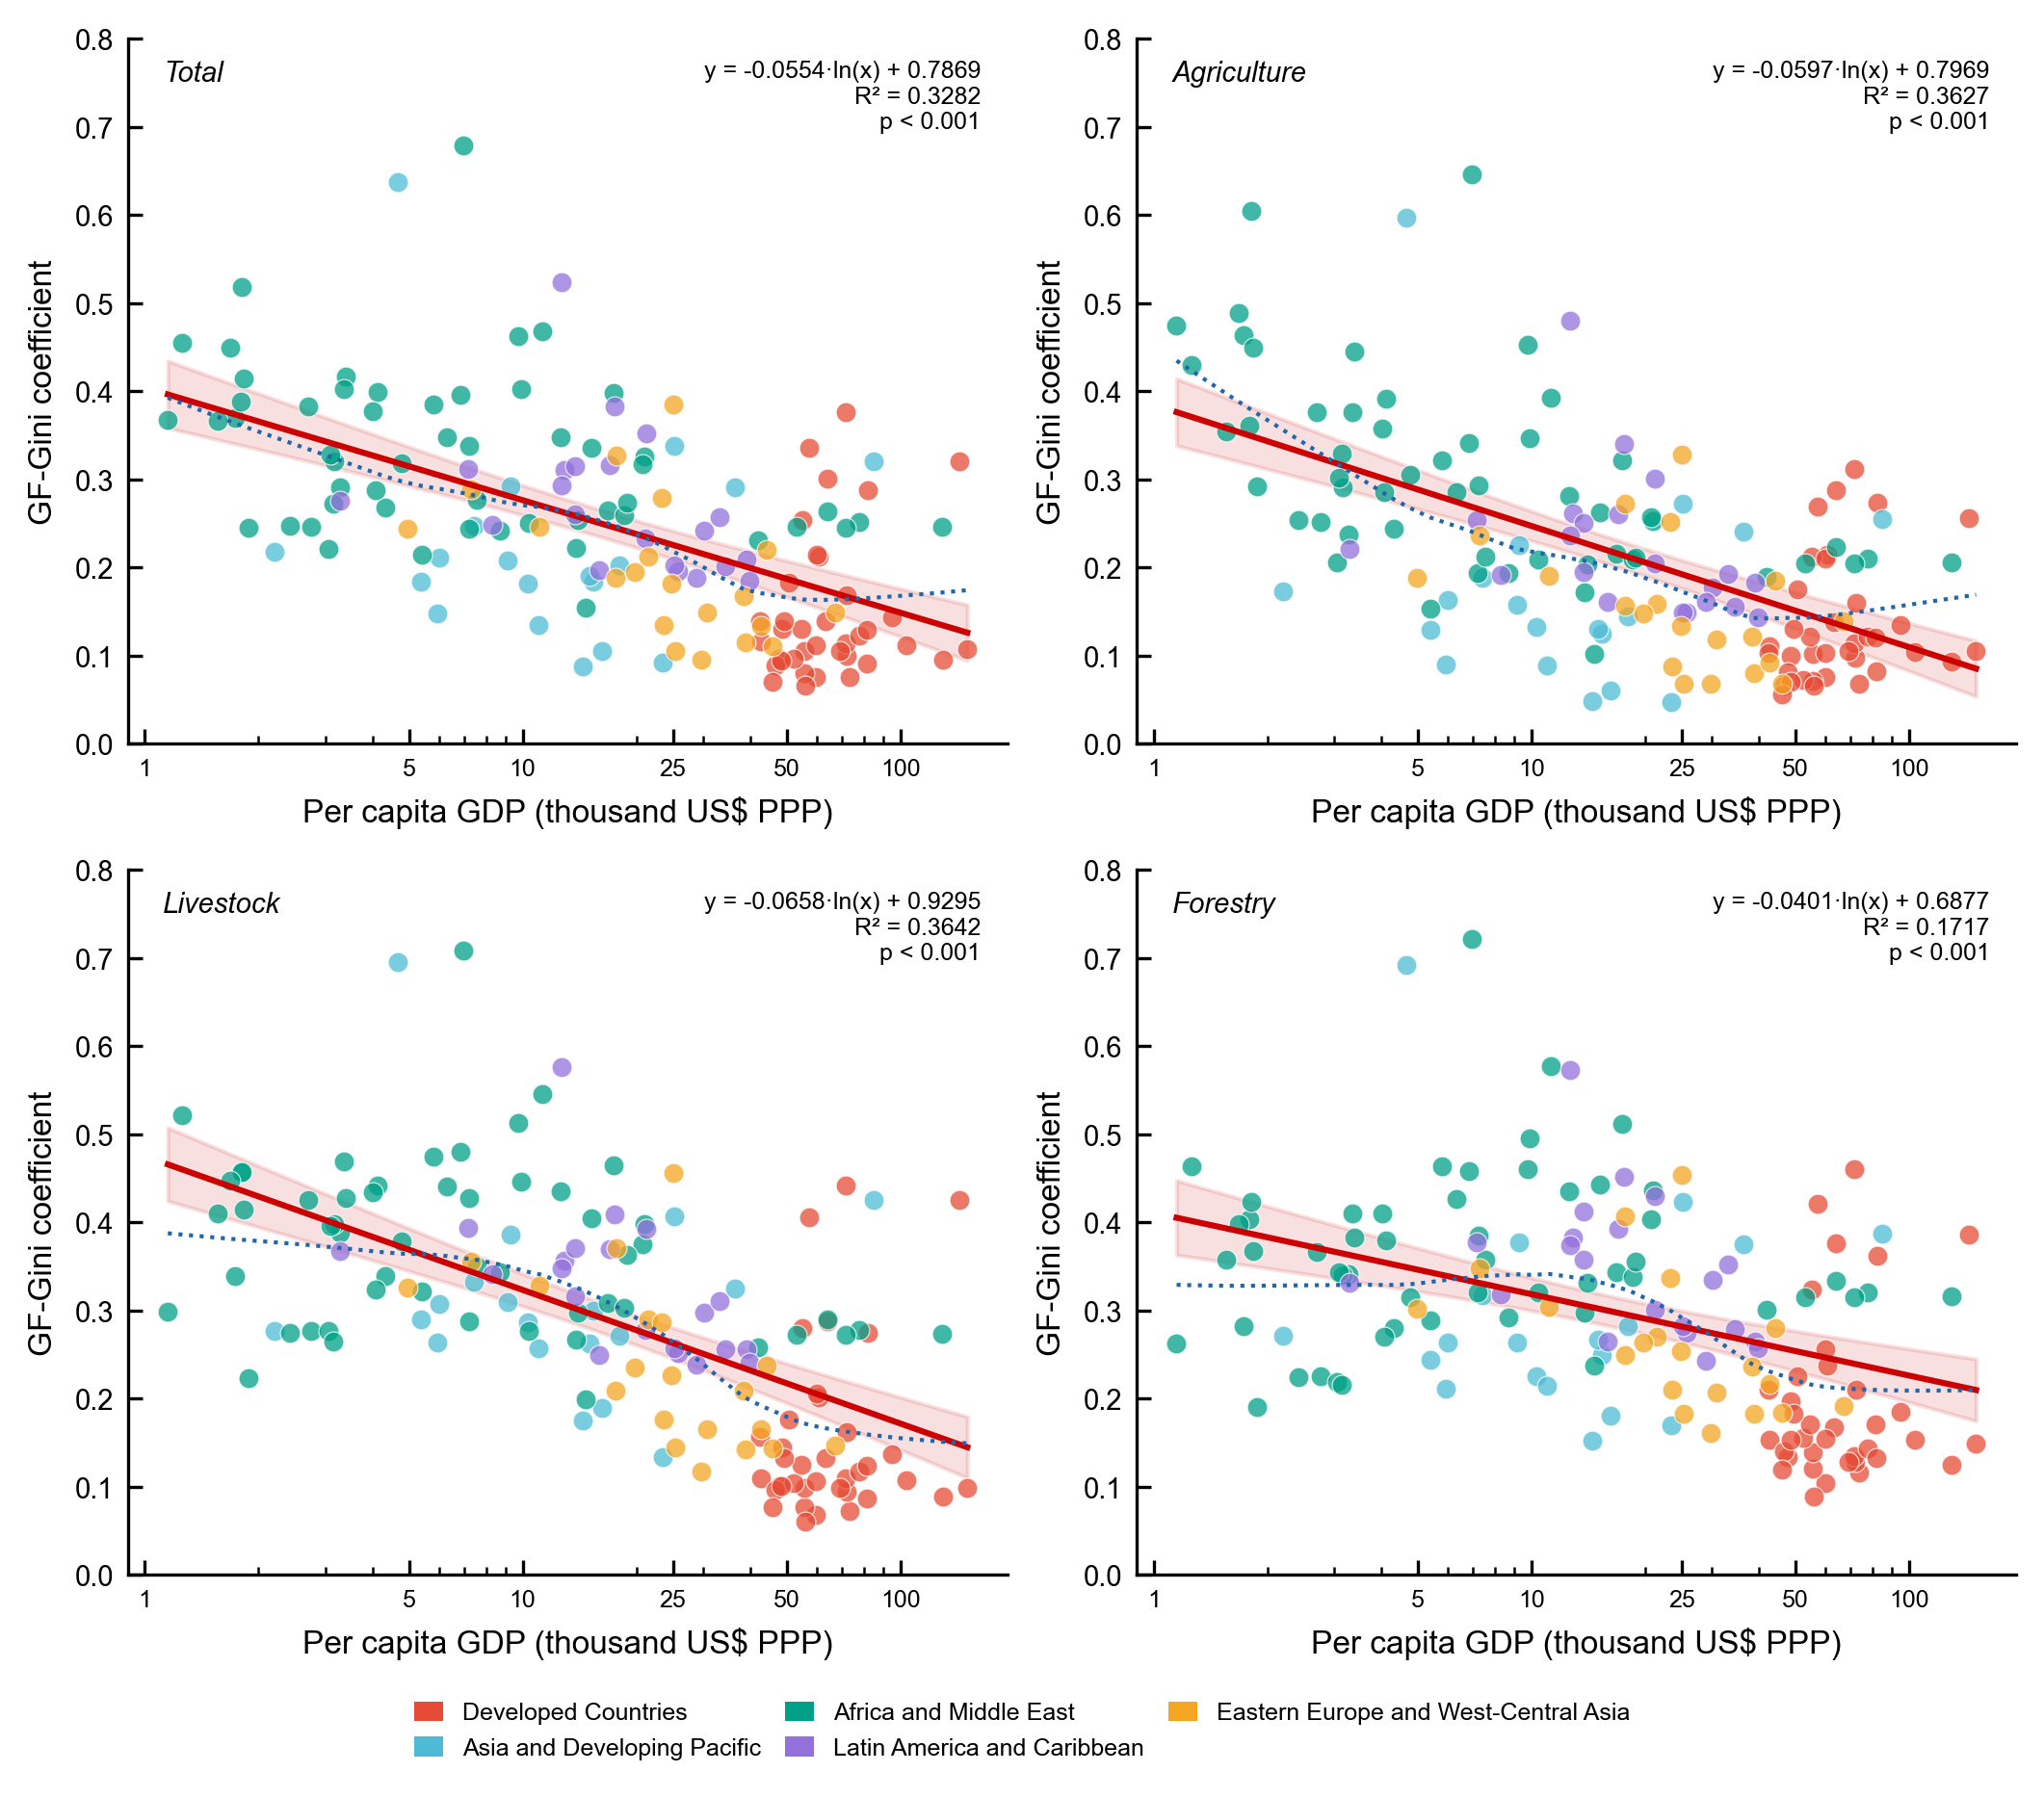

[S8] Saved → E:\phdstudy\BiodiversityPHD-2ndpaper\BiodiversityPHD-2ndpaper\results\figures\Fig_Gini_GDP_regression.pdf
[S8] Saved → E:\phdstudy\BiodiversityPHD-2ndpaper\BiodiversityPHD-2ndpaper\results\figures\Fig_Gini_GDP_regression.png

GF-Gini vs GDP Regression — Biodiversity Loss Footprint 2023
GDP source: local cache: E:\phdstudy\reference\WB_GDP_PPP_2023.csv
Countries with valid data: 160

REGRESSION RESULTS:
  Total         : r = -0.57, R² = 0.33, p < 0.001, slope = -0.0554
  Agriculture   : r = -0.60, R² = 0.36, p < 0.001, slope = -0.0597
  Livestock     : r = -0.60, R² = 0.36, p < 0.001, slope = -0.0658
  Forestry      : r = -0.41, R² = 0.17, p < 0.001, slope = -0.0401

Steepest slope (most income-sensitive) : Livestock
Flattest  slope (least income-sensitive): Forestry


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1: Imports and global configuration
# ══════════════════════════════════════════════════════════════════════════════
import os, warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.stats as stats
from statsmodels.nonparametric.smoothers_lowess import lowess
import requests

warnings.filterwarnings('ignore')

mpl.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial'],
    'font.size': 7, 'axes.labelsize': 8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'figure.dpi': 300, 'savefig.dpi': 300, 'pdf.fonttype': 42,
})

BASE_DIR = r'E:\phdstudy\BiodiversityPHD-2ndpaper'
NB_DIR   = rf'{BASE_DIR}\BiodiversityPHD-2ndpaper'
FP_DIR   = rf'{BASE_DIR}\household_expenditure\income_group_footprint'
REF_DIR  = r'E:\phdstudy\reference'
FIG_DIR  = rf'{NB_DIR}\results\figures'
CSV_DIR  = rf'{NB_DIR}\results\gini_gdp_regression'
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(CSV_DIR, exist_ok=True)

REGION_COLORS = {
    'Developed Countries'                  : '#E64B35',  # red — kept
    'Asia and Developing Pacific'          : '#4DBBD5',  # blue — kept
    'Africa and Middle East'               : '#00A087',  # teal — kept
    'Latin America and Caribbean'          : '#9370DB',  # purple — replaced #3C5488 (dark blue)
    'Eastern Europe and West-Central Asia' : '#F5A623',  # amber — replaced #F39B7F (salmon red)
}
CATEGORIES = ['Total', 'Agriculture', 'Livestock', 'Forestry']

print('[S1] Configuration complete.')

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2: Load total footprint data
# ══════════════════════════════════════════════════════════════════════════════
fp_long = pd.read_csv(rf'{FP_DIR}\footprint_income_long_2023.csv')
fp_long = fp_long[fp_long['Population'] > 0].copy()

# Per-bin income in 2023 PPP USD (geometric interpolation between $25 and $975,000)
fp_long['bin_income_ppp'] = (
    25.0 * (975_000.0 / 25.0) ** (fp_long['BinIndex'] / 200) * 1.3546
)

print(f'[S2] footprint_income_long_2023.csv loaded: '
      f'{fp_long["Country"].nunique()} countries, {len(fp_long)} valid (Population>0) rows.')

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3: Load sector footprint and classification
# ══════════════════════════════════════════════════════════════════════════════

# Global sector footprint matrix: index=Sector0..119, cols=Bin0..200
fp_sec_bin = pd.read_csv(rf'{FP_DIR}\footprint_sector_by_bin_2023.csv', index_col=0)
bin_cols   = [f'Bin{i}' for i in range(201)]
fp_sec_bin = fp_sec_bin.reindex(columns=bin_cols, fill_value=0.0)

# Sector classification: Lfd_Nr, Sector_names, class
sector_cls = pd.read_excel(rf'{BASE_DIR}\sector_class.xlsx')
sector_cls['Sector_key'] = 'Sector' + (sector_cls['Lfd_Nr'] - 1).astype(str)

# Derive 4class from 'class' column via keyword matching — no hardcoded label strings
AGRI_KW = ('cereal', 'crop', 'veg', 'fruit', 'sugar', 'tobacco', 'legum', 'fibre')
LIVE_KW  = ('cattle', 'sheep', 'animal')
FORE_KW  = ('forest',)

def assign_4class(cls_str):
    s = cls_str.lower()
    if any(k in s for k in AGRI_KW): return 'Agriculture'
    if any(k in s for k in LIVE_KW):  return 'Livestock'
    if any(k in s for k in FORE_KW):  return 'Forestry'
    return 'Others'

sector_cls['4class'] = sector_cls['class'].apply(assign_4class)
print('4class sector counts (read from sector_class.xlsx):')
for grp, cnt in sector_cls.groupby('4class').size().items():
    print(f'  {grp}: {cnt} sectors')

# Aggregate sector footprint by 4class: sum across matching sector rows, per bin
fp_cls = {
    cls_name: fp_sec_bin.loc[
        fp_sec_bin.index.isin(grp['Sector_key'].tolist()), bin_cols
    ].sum(axis=0)
    for cls_name, grp in sector_cls.groupby('4class')
}

# Global total footprint per bin (all 120 sectors) — denominator for proportioning
global_fp_by_bin = fp_sec_bin[bin_cols].sum(axis=0)   # Series, index=Bin0..Bin200

print(f'[S3] Sector classification done. Categories: {list(fp_cls.keys())}')

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 4: Load GDP and region data, merge with country list
# ══════════════════════════════════════════════════════════════════════════════
GDP_CACHE = rf'{REF_DIR}\WB_GDP_PPP_2023.csv'

def fetch_wb_gdp():
    """Fetch GDP per capita PPP 2023 from World Bank API (NY.GDP.PCAP.PP.CD)."""
    url = ('https://api.worldbank.org/v2/country/all/indicator/NY.GDP.PCAP.PP.CD'
           '?date=2023&format=json&per_page=300')
    try:
        r    = requests.get(url, timeout=30)
        data = r.json()[1]
        rows = [{'ISO3': d['countryiso3code'], 'GDP_PPP': d['value']}
                for d in data if d['value'] is not None and d['countryiso3code']]
        return pd.DataFrame(rows)
    except Exception as e:
        print(f'World Bank API error: {e}')
        return pd.DataFrame(columns=['ISO3', 'GDP_PPP'])

cc = pd.read_csv(rf'{REF_DIR}\nationlist_categorized_titlecase.csv')

if os.path.exists(GDP_CACHE):
    gdp_df     = pd.read_csv(GDP_CACHE)
    gdp_source = f'local cache: {GDP_CACHE}'
    print(f'Loaded GDP from cache: {len(gdp_df)} records.')
else:
    print('GDP cache not found — fetching from World Bank API ...')
    gdp_df     = fetch_wb_gdp()
    gdp_source = 'World Bank API (indicator NY.GDP.PCAP.PP.CD, year 2023)'
    if len(gdp_df) > 100:
        gdp_df.to_csv(GDP_CACHE, index=False)
        print(f'Saved GDP cache \u2192 {GDP_CACHE}')

if gdp_df['GDP_PPP'].notna().sum() < 100:
    print('Insufficient GDP records — retrying World Bank API ...')
    gdp_api = fetch_wb_gdp()
    if gdp_api['GDP_PPP'].notna().sum() > gdp_df['GDP_PPP'].notna().sum():
        gdp_df     = gdp_api
        gdp_source = 'World Bank API (indicator NY.GDP.PCAP.PP.CD, year 2023)'
        gdp_df.to_csv(GDP_CACHE, index=False)

country_ref = (
    cc[['Country_Name', 'Region_acronyms', 'typeA']]
    .merge(gdp_df[['ISO3', 'GDP_PPP']],
           left_on='Region_acronyms', right_on='ISO3', how='left')
    .drop(columns='ISO3')
)

print(f'[S4] GDP source: {gdp_source}')
print(f'     Countries with valid GDP: '
      f'{country_ref["GDP_PPP"].notna().sum()} / {len(country_ref)}')

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 5: Compute GF-Gini coefficients per country per category
# ══════════════════════════════════════════════════════════════════════════════

def calc_gf_gini(fp_vec, pop_vec, min_groups=10):
    """
    GF-Gini (Li et al. 2024 Nat. Clim. Change, eq. 7).
    Income groups (bins) reordered ascending by per-capita footprint.
    D_m = population share, Y_m = footprint share, T_m = cumulative footprint share.
    Gini = sum(D*Y) + 2*sum(D*(1-T)) - 1
    Returns NaN when fewer than min_groups valid groups or zero total footprint.
    """
    fp  = np.asarray(fp_vec,  dtype=float)
    pop = np.asarray(pop_vec, dtype=float)
    ok  = np.isfinite(fp) & np.isfinite(pop) & (pop > 0) & (fp >= 0)
    fp, pop = fp[ok], pop[ok]
    if len(fp) < min_groups or fp.sum() == 0:
        return np.nan
    order   = np.argsort(fp / pop)          # ascending per-capita footprint
    fp, pop = fp[order], pop[order]
    D = pop / pop.sum()
    Y = fp  / fp.sum()
    T = np.cumsum(Y)
    return float(np.sum(D * Y) + 2.0 * np.sum(D * (1.0 - T)) - 1.0)

# Pre-extract arrays indexed by BinIndex (0..200) for fast vectorised lookup
sector_fp_arr = {cat: fp_cls[cat].values for cat in ('Agriculture', 'Livestock', 'Forestry')}
global_fp_arr = global_fp_by_bin.values   # shape (201,)

records = []
for country in fp_long['Country'].unique():
    cdf    = fp_long[fp_long['Country'] == country]
    bins   = cdf['BinIndex'].values
    fp_tot = cdf['Footprint_PDF'].values
    pop    = cdf['Population'].values

    # Total GF-Gini: use per-country per-bin footprint directly
    gini_total = calc_gf_gini(fp_tot, pop)

    # Sector GF-Gini: allocate country bin footprint by global sector proportion per bin
    # fp_cat[b] = fp_cls_C[b] / global_fp[b] * fp_country[b]
    gini_sec = {}
    for cat in ('Agriculture', 'Livestock', 'Forestry'):
        sec_fp   = sector_fp_arr[cat][bins]     # global sector fp for these bins
        glob_tot = global_fp_arr[bins]          # global total fp for these bins
        denom    = np.where(glob_tot > 0, glob_tot, np.nan)
        fp_cat   = sec_fp / denom * fp_tot      # country-attributed sector footprint
        gini_sec[cat] = calc_gf_gini(fp_cat, pop)

    records.append({
        'Country'          : country,
        'Gini_Total'       : gini_total,
        'Gini_Agriculture' : gini_sec['Agriculture'],
        'Gini_Livestock'   : gini_sec['Livestock'],
        'Gini_Forestry'    : gini_sec['Forestry'],
    })

gini_df = (
    pd.DataFrame(records)
    .merge(country_ref[['Country_Name', 'typeA', 'GDP_PPP']],
           left_on='Country', right_on='Country_Name', how='left')
    .drop(columns='Country_Name')
)

print('[S5] GF-Gini computation complete.')
for cat in CATEGORIES:
    n = gini_df[f'Gini_{cat}'].notna().sum()
    print(f'     {cat:<14}: {n} valid countries')

out_cols = ['Country', 'typeA', 'GDP_PPP',
            'Gini_Total', 'Gini_Agriculture', 'Gini_Livestock', 'Gini_Forestry']
gini_df[out_cols].to_csv(rf'{CSV_DIR}\gini_by_country_2023.csv', index=False)
print(f'     Saved \u2192 {CSV_DIR}\\gini_by_country_2023.csv')

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 6: Logarithmic regression per category
# ══════════════════════════════════════════════════════════════════════════════
reg_results = {}

for cat in CATEGORIES:
    col  = f'Gini_{cat}'
    sub  = gini_df[['GDP_PPP', col, 'typeA']].dropna().copy()
    x    = sub['GDP_PPP'].values
    y    = sub[col].values
    ln_x = np.log(x)

    slope, intercept, r, p, _ = stats.linregress(ln_x, y)
    r2    = r ** 2
    p_str = '< 0.001' if p < 0.001 else f'= {p:.4f}'
    n     = len(sub)

    # Residual SE and critical t-value for 95% CI band
    y_hat    = slope * ln_x + intercept
    ln_x_mean = ln_x.mean()
    ln_x_ss   = ((ln_x - ln_x_mean) ** 2).sum()
    se_resid  = np.sqrt(((y - y_hat) ** 2).sum() / (n - 2))
    t_crit    = stats.t.ppf(0.975, df=n - 2)

    # LOWESS trend (frac=0.5, sorted by ln_x for plotting)
    lw = lowess(y, ln_x, frac=0.5, it=3, return_sorted=True)

    reg_results[cat] = dict(
        n=n, slope=slope, intercept=intercept,
        r=r, r2=r2, p=p, p_str=p_str,
        ln_x_mean=ln_x_mean, ln_x_ss=ln_x_ss,
        se_resid=se_resid, t_crit=t_crit,
        lowess_ln_x=lw[:, 0], lowess_y=lw[:, 1],
        sub=sub, col=col,
    )
    print(f'[S6] {cat:<14}: n={n:3d}, r={r:+.3f}, R\u00b2={r2:.3f}, '
          f'p {p_str}, slope={slope:+.4f}')

reg_rows = [
    dict(category=cat,
         n_countries=rr['n'],
         slope=rr['slope'],
         intercept=rr['intercept'],
         r_pearson=rr['r'],
         r_squared=rr['r2'],
         p_value=rr['p'],
         equation_str=f"y = {rr['slope']:.4f}\u00b7ln(x) + {rr['intercept']:.4f}")
    for cat, rr in reg_results.items()
]
pd.DataFrame(reg_rows).to_csv(rf'{CSV_DIR}\regression_results_2023.csv', index=False)
print(f'[S6] Saved \u2192 {CSV_DIR}\\regression_results_2023.csv')

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 7: Build 2x2 publication figure (180 mm x 160 mm, Nature standard)
# ══════════════════════════════════════════════════════════════════════════════
MM2IN      = 1 / 25.4
fig, axes  = plt.subplots(2, 2, figsize=(180 * MM2IN, 160 * MM2IN))
gdp_ticks  = [1_000, 5_000, 10_000, 25_000, 50_000, 100_000]

for idx, cat in enumerate(CATEGORIES):
    ax  = axes.flat[idx]
    rr  = reg_results[cat]
    sub = rr['sub']
    col = rr['col']

    # -- Scatter: one point per country, colored by typeA region --
    for region, color in REGION_COLORS.items():
        m = sub['typeA'] == region
        ax.scatter(sub.loc[m, 'GDP_PPP'], sub.loc[m, col],
                   c=color, s=25, alpha=0.75,
                   edgecolors='white', linewidths=0.3, zorder=3, label=region)

    # -- Log regression line + 95% CI band --
    x_fit  = np.linspace(sub['GDP_PPP'].min(), sub['GDP_PPP'].max(), 400)
    ln_fit = np.log(x_fit)
    y_fit  = rr['slope'] * ln_fit + rr['intercept']
    ci     = (rr['t_crit'] * rr['se_resid']
               * np.sqrt(1 / rr['n']
                         + (ln_fit - rr['ln_x_mean']) ** 2 / rr['ln_x_ss']))
    line_col = '#CC0000' if rr['p'] <= 0.05 else '#888888'
    ax.plot(x_fit, y_fit, color=line_col, lw=1.5, zorder=4)
    ax.fill_between(x_fit, y_fit - ci, y_fit + ci,
                    color=line_col, alpha=0.12, zorder=2)

    # -- LOWESS trend (blue dotted) --
    ax.plot(np.exp(rr['lowess_ln_x']), rr['lowess_y'],
            color='#2166AC', lw=1.0, ls='dotted', zorder=5)

    # -- In-panel annotation: plain Unicode text with Arial font --
    ann = (f"y = {rr['slope']:.4f}\u00b7ln(x) + {rr['intercept']:.4f}\n"
           f"R\u00b2 = {rr['r2']:.4f}\n"
           f"p {rr['p_str']}")
    if rr['slope'] >= 0:
        ax_x, ax_y, ha_a, va_a = 0.03, 0.05, 'left', 'bottom'
    else:
        ax_x, ax_y, ha_a, va_a = 0.97, 0.97, 'right', 'top'
    # Use plain Unicode (no LaTeX) so fontfamily='Arial' takes effect
    ax.text(ax_x, ax_y, ann, transform=ax.transAxes, fontsize=6,
            fontfamily='Arial', ha=ha_a, va=va_a,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.75, ec='none'))

    if rr['p'] > 0.05:
        ax.text(0.5, 0.5, 'n.s.', transform=ax.transAxes, fontsize=14,
                fontweight='bold', color='#888888', ha='center', va='center', alpha=0.5)

    # -- Axes formatting --
    ax.set_xscale('log')
    ax.set_xticks(gdp_ticks)
    ax.set_xticklabels([f'{v // 1000:g}' for v in gdp_ticks], fontsize=6)
    ax.set_xlabel('Per capita GDP (thousand US$ PPP)', fontsize=8)
    y_max = max(0.8, float(sub[col].max()) * 1.08)
    ax.set_ylim(0, y_max)
    ax.set_ylabel('GF-Gini coefficient', fontsize=8)

    # Category label (italic, inside panel)
    ax.text(0.04, 0.97, cat, transform=ax.transAxes,
            fontsize=7, ha='left', va='top', style='italic')

    # Panel labels (a)(b)(c)(d) removed per request

# -- Shared horizontal legend: moved up to sit just below the plot frame --
handles = [mpatches.Patch(facecolor=c, label=r) for r, c in REGION_COLORS.items()]
fig.legend(handles=handles, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, 0.02), frameon=False,
           fontsize=6, handlelength=1.2, handleheight=0.9, columnspacing=1.0)

# Reduced bottom margin to pull legend closer to figure frame
fig.tight_layout(rect=[0, 0.07, 1, 1])
print('[S7] Figure assembled.')

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 8: Save outputs and print summary
# ══════════════════════════════════════════════════════════════════════════════
pdf_path = rf'{FIG_DIR}\Fig_Gini_GDP_regression.pdf'
png_path = rf'{FIG_DIR}\Fig_Gini_GDP_regression.png'
fig.savefig(pdf_path, bbox_inches='tight')
fig.savefig(png_path, bbox_inches='tight', dpi=300)
plt.show()
print(f'[S8] Saved \u2192 {pdf_path}')
print(f'[S8] Saved \u2192 {png_path}')

slopes   = {cat: reg_results[cat]['slope'] for cat in CATEGORIES}
steepest = max(slopes, key=lambda c: abs(slopes[c]))
flattest = min(slopes, key=lambda c: abs(slopes[c]))

print('\n' + '=' * 60)
print('GF-Gini vs GDP Regression \u2014 Biodiversity Loss Footprint 2023')
print('=' * 60)
print(f'GDP source: {gdp_source}')
print(f'Countries with valid data: {gini_df["Gini_Total"].notna().sum()}')
print('\nREGRESSION RESULTS:')
for cat in CATEGORIES:
    rr = reg_results[cat]
    print(f"  {cat:<14}: r = {rr['r']:+.2f}, R\u00b2 = {rr['r2']:.2f}, "
          f"p {rr['p_str']}, slope = {rr['slope']:+.4f}")
print(f'\nSteepest slope (most income-sensitive) : {steepest}')
print(f'Flattest  slope (least income-sensitive): {flattest}')
print('=' * 60)

[S1] Configuration complete.
[S2] footprint_income_long_2023.csv loaded: 163 countries, 25436 valid (Population>0) rows.
4class sector counts (read from sector_class.xlsx):
  Agriculture: 9 sectors
  Forestry: 1 sectors
  Livestock: 5 sectors
  Others: 105 sectors
[S3] Sector classification done. Categories: ['Agriculture', 'Forestry', 'Livestock', 'Others']
Loaded GDP from cache: 241 records.
[S4] GDP source: local cache: E:\phdstudy\reference\WB_GDP_PPP_2023.csv
     Countries with valid GDP: 152 / 164
[S5] GF-Gini computation complete.
     Total         : 160 valid countries
     Agriculture   : 160 valid countries
     Livestock     : 160 valid countries
     Forestry      : 160 valid countries
     Saved → E:\phdstudy\BiodiversityPHD-2ndpaper\BiodiversityPHD-2ndpaper\results\gini_gdp_regression\gini_by_country_2023.csv
[S6] Total         : n=151, r=-0.573, R²=0.328, p < 0.001, slope=-0.0554
[S6] Agriculture   : n=151, r=-0.602, R²=0.363, p < 0.001, slope=-0.0597
[S6] Livestock   

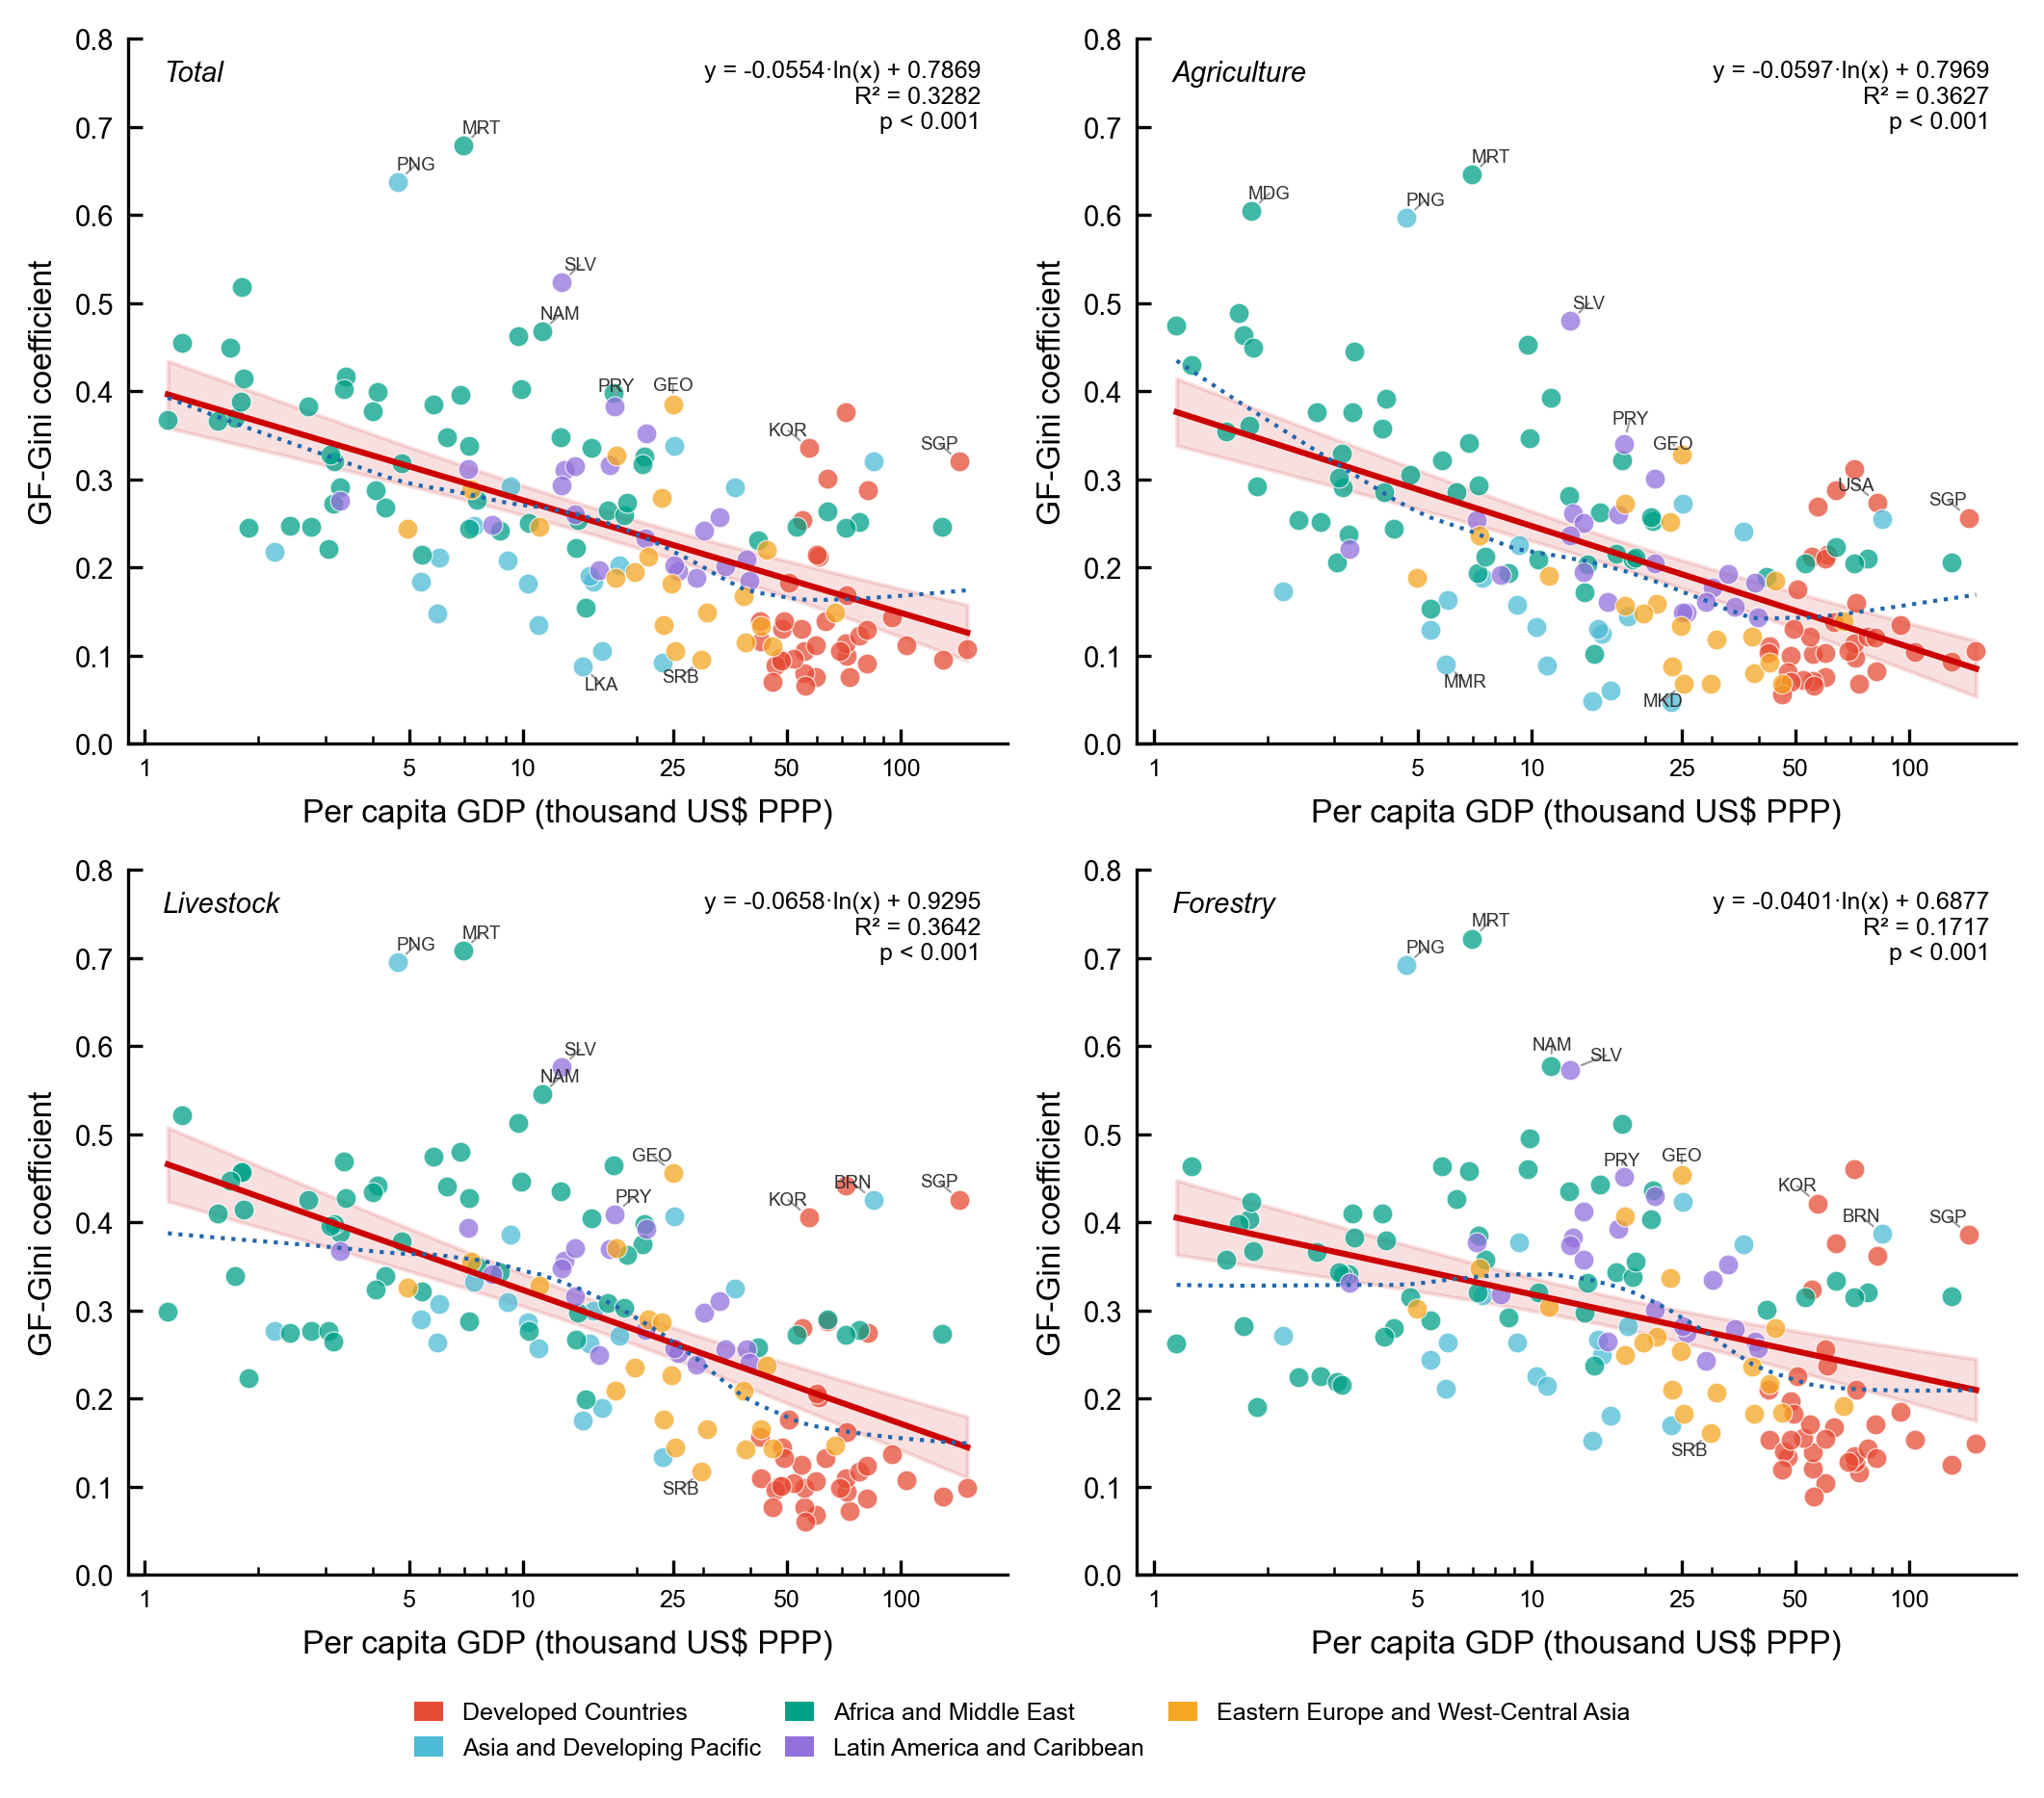

[S8] Saved → E:\phdstudy\BiodiversityPHD-2ndpaper\BiodiversityPHD-2ndpaper\results\figures\Fig_Gini_GDP_regression.pdf
[S8] Saved → E:\phdstudy\BiodiversityPHD-2ndpaper\BiodiversityPHD-2ndpaper\results\figures\Fig_Gini_GDP_regression.png

GF-Gini vs GDP Regression — Biodiversity Loss Footprint 2023
GDP source: local cache: E:\phdstudy\reference\WB_GDP_PPP_2023.csv
Countries with valid data: 160

REGRESSION RESULTS:
  Total         : r = -0.57, R² = 0.33, p < 0.001, slope = -0.0554
  Agriculture   : r = -0.60, R² = 0.36, p < 0.001, slope = -0.0597
  Livestock     : r = -0.60, R² = 0.36, p < 0.001, slope = -0.0658
  Forestry      : r = -0.41, R² = 0.17, p < 0.001, slope = -0.0401

Steepest slope (most income-sensitive) : Livestock
Flattest  slope (least income-sensitive): Forestry


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1: Imports and global configuration
# ══════════════════════════════════════════════════════════════════════════════
import os, warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.stats as stats
from statsmodels.nonparametric.smoothers_lowess import lowess
import requests

warnings.filterwarnings('ignore')

mpl.rcParams.update({
    'font.family': 'sans-serif', 'font.sans-serif': ['Arial'],
    'font.size': 7, 'axes.labelsize': 8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'figure.dpi': 300, 'savefig.dpi': 300, 'pdf.fonttype': 42,
})

BASE_DIR = r'E:\phdstudy\BiodiversityPHD-2ndpaper'
NB_DIR   = rf'{BASE_DIR}\BiodiversityPHD-2ndpaper'
FP_DIR   = rf'{BASE_DIR}\household_expenditure\income_group_footprint'
REF_DIR  = r'E:\phdstudy\reference'
FIG_DIR  = rf'{NB_DIR}\results\figures'
CSV_DIR  = rf'{NB_DIR}\results\gini_gdp_regression'
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(CSV_DIR, exist_ok=True)

REGION_COLORS = {
    'Developed Countries'                  : '#E64B35',
    'Asia and Developing Pacific'          : '#4DBBD5',
    'Africa and Middle East'               : '#00A087',
    'Latin America and Caribbean'          : '#9370DB',
    'Eastern Europe and West-Central Asia' : '#F5A623',
}
CATEGORIES = ['Total', 'Agriculture', 'Livestock', 'Forestry']

print('[S1] Configuration complete.')

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2: Load total footprint data
# ══════════════════════════════════════════════════════════════════════════════
fp_long = pd.read_csv(rf'{FP_DIR}\footprint_income_long_2023.csv')
fp_long = fp_long[fp_long['Population'] > 0].copy()

fp_long['bin_income_ppp'] = (
    25.0 * (975_000.0 / 25.0) ** (fp_long['BinIndex'] / 200) * 1.3546
)

print(f'[S2] footprint_income_long_2023.csv loaded: '
      f'{fp_long["Country"].nunique()} countries, {len(fp_long)} valid (Population>0) rows.')

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3: Load sector footprint and classification
# ══════════════════════════════════════════════════════════════════════════════
fp_sec_bin = pd.read_csv(rf'{FP_DIR}\footprint_sector_by_bin_2023.csv', index_col=0)
bin_cols   = [f'Bin{i}' for i in range(201)]
fp_sec_bin = fp_sec_bin.reindex(columns=bin_cols, fill_value=0.0)

sector_cls = pd.read_excel(rf'{BASE_DIR}\sector_class.xlsx')
sector_cls['Sector_key'] = 'Sector' + (sector_cls['Lfd_Nr'] - 1).astype(str)

AGRI_KW = ('cereal', 'crop', 'veg', 'fruit', 'sugar', 'tobacco', 'legum', 'fibre')
LIVE_KW  = ('cattle', 'sheep', 'animal')
FORE_KW  = ('forest',)

def assign_4class(cls_str):
    s = cls_str.lower()
    if any(k in s for k in AGRI_KW): return 'Agriculture'
    if any(k in s for k in LIVE_KW):  return 'Livestock'
    if any(k in s for k in FORE_KW):  return 'Forestry'
    return 'Others'

sector_cls['4class'] = sector_cls['class'].apply(assign_4class)
print('4class sector counts (read from sector_class.xlsx):')
for grp, cnt in sector_cls.groupby('4class').size().items():
    print(f'  {grp}: {cnt} sectors')

fp_cls = {
    cls_name: fp_sec_bin.loc[
        fp_sec_bin.index.isin(grp['Sector_key'].tolist()), bin_cols
    ].sum(axis=0)
    for cls_name, grp in sector_cls.groupby('4class')
}

global_fp_by_bin = fp_sec_bin[bin_cols].sum(axis=0)

print(f'[S3] Sector classification done. Categories: {list(fp_cls.keys())}')

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 4: Load GDP and region data, merge with country list
# ══════════════════════════════════════════════════════════════════════════════
GDP_CACHE = rf'{REF_DIR}\WB_GDP_PPP_2023.csv'

def fetch_wb_gdp():
    """Fetch GDP per capita PPP 2023 from World Bank API (NY.GDP.PCAP.PP.CD)."""
    url = ('https://api.worldbank.org/v2/country/all/indicator/NY.GDP.PCAP.PP.CD'
           '?date=2023&format=json&per_page=300')
    try:
        r    = requests.get(url, timeout=30)
        data = r.json()[1]
        rows = [{'ISO3': d['countryiso3code'], 'GDP_PPP': d['value']}
                for d in data if d['value'] is not None and d['countryiso3code']]
        return pd.DataFrame(rows)
    except Exception as e:
        print(f'World Bank API error: {e}')
        return pd.DataFrame(columns=['ISO3', 'GDP_PPP'])

cc = pd.read_csv(rf'{REF_DIR}\nationlist_categorized_titlecase.csv')

if os.path.exists(GDP_CACHE):
    gdp_df     = pd.read_csv(GDP_CACHE)
    gdp_source = f'local cache: {GDP_CACHE}'
    print(f'Loaded GDP from cache: {len(gdp_df)} records.')
else:
    print('GDP cache not found — fetching from World Bank API ...')
    gdp_df     = fetch_wb_gdp()
    gdp_source = 'World Bank API (indicator NY.GDP.PCAP.PP.CD, year 2023)'
    if len(gdp_df) > 100:
        gdp_df.to_csv(GDP_CACHE, index=False)
        print(f'Saved GDP cache \u2192 {GDP_CACHE}')

if gdp_df['GDP_PPP'].notna().sum() < 100:
    print('Insufficient GDP records — retrying World Bank API ...')
    gdp_api = fetch_wb_gdp()
    if gdp_api['GDP_PPP'].notna().sum() > gdp_df['GDP_PPP'].notna().sum():
        gdp_df     = gdp_api
        gdp_source = 'World Bank API (indicator NY.GDP.PCAP.PP.CD, year 2023)'
        gdp_df.to_csv(GDP_CACHE, index=False)

country_ref = (
    cc[['Country_Name', 'Region_acronyms', 'typeA']]
    .merge(gdp_df[['ISO3', 'GDP_PPP']],
           left_on='Region_acronyms', right_on='ISO3', how='left')
    .drop(columns='ISO3')
)

print(f'[S4] GDP source: {gdp_source}')
print(f'     Countries with valid GDP: '
      f'{country_ref["GDP_PPP"].notna().sum()} / {len(country_ref)}')

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 5: Compute GF-Gini coefficients per country per category
# ══════════════════════════════════════════════════════════════════════════════

def calc_gf_gini(fp_vec, pop_vec, min_groups=10):
    """
    GF-Gini (Li et al. 2024 Nat. Clim. Change, eq. 7).
    Income groups (bins) reordered ascending by per-capita footprint.
    D_m = population share, Y_m = footprint share, T_m = cumulative footprint share.
    Gini = sum(D*Y) + 2*sum(D*(1-T)) - 1
    Returns NaN when fewer than min_groups valid groups or zero total footprint.
    """
    fp  = np.asarray(fp_vec,  dtype=float)
    pop = np.asarray(pop_vec, dtype=float)
    ok  = np.isfinite(fp) & np.isfinite(pop) & (pop > 0) & (fp >= 0)
    fp, pop = fp[ok], pop[ok]
    if len(fp) < min_groups or fp.sum() == 0:
        return np.nan
    order   = np.argsort(fp / pop)
    fp, pop = fp[order], pop[order]
    D = pop / pop.sum()
    Y = fp  / fp.sum()
    T = np.cumsum(Y)
    return float(np.sum(D * Y) + 2.0 * np.sum(D * (1.0 - T)) - 1.0)

sector_fp_arr = {cat: fp_cls[cat].values for cat in ('Agriculture', 'Livestock', 'Forestry')}
global_fp_arr = global_fp_by_bin.values

records = []
for country in fp_long['Country'].unique():
    cdf    = fp_long[fp_long['Country'] == country]
    bins   = cdf['BinIndex'].values
    fp_tot = cdf['Footprint_PDF'].values
    pop    = cdf['Population'].values

    gini_total = calc_gf_gini(fp_tot, pop)

    gini_sec = {}
    for cat in ('Agriculture', 'Livestock', 'Forestry'):
        sec_fp   = sector_fp_arr[cat][bins]
        glob_tot = global_fp_arr[bins]
        denom    = np.where(glob_tot > 0, glob_tot, np.nan)
        fp_cat   = sec_fp / denom * fp_tot
        gini_sec[cat] = calc_gf_gini(fp_cat, pop)

    records.append({
        'Country'          : country,
        'Gini_Total'       : gini_total,
        'Gini_Agriculture' : gini_sec['Agriculture'],
        'Gini_Livestock'   : gini_sec['Livestock'],
        'Gini_Forestry'    : gini_sec['Forestry'],
    })

# Retain Region_acronyms as ISO3 for country label annotation
gini_df = (
    pd.DataFrame(records)
    .merge(country_ref[['Country_Name', 'typeA', 'GDP_PPP', 'Region_acronyms']],
           left_on='Country', right_on='Country_Name', how='left')
    .drop(columns='Country_Name')
    .rename(columns={'Region_acronyms': 'ISO3'})
)

print('[S5] GF-Gini computation complete.')
for cat in CATEGORIES:
    n = gini_df[f'Gini_{cat}'].notna().sum()
    print(f'     {cat:<14}: {n} valid countries')

out_cols = ['Country', 'ISO3', 'typeA', 'GDP_PPP',
            'Gini_Total', 'Gini_Agriculture', 'Gini_Livestock', 'Gini_Forestry']
gini_df[out_cols].to_csv(rf'{CSV_DIR}\gini_by_country_2023.csv', index=False)
print(f'     Saved \u2192 {CSV_DIR}\\gini_by_country_2023.csv')

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 6: Logarithmic regression per category
# ══════════════════════════════════════════════════════════════════════════════
reg_results = {}

for cat in CATEGORIES:
    col  = f'Gini_{cat}'
    sub  = gini_df[['GDP_PPP', col, 'typeA', 'ISO3']].dropna().copy()
    x    = sub['GDP_PPP'].values
    y    = sub[col].values
    ln_x = np.log(x)

    slope, intercept, r, p, _ = stats.linregress(ln_x, y)
    r2    = r ** 2
    p_str = '< 0.001' if p < 0.001 else f'= {p:.4f}'
    n     = len(sub)

    y_hat     = slope * ln_x + intercept
    ln_x_mean = ln_x.mean()
    ln_x_ss   = ((ln_x - ln_x_mean) ** 2).sum()
    se_resid  = np.sqrt(((y - y_hat) ** 2).sum() / (n - 2))
    t_crit    = stats.t.ppf(0.975, df=n - 2)

    lw = lowess(y, ln_x, frac=0.5, it=3, return_sorted=True)

    # Store residuals per country for outlier-based label selection
    sub = sub.copy()
    sub['residual'] = y - y_hat

    reg_results[cat] = dict(
        n=n, slope=slope, intercept=intercept,
        r=r, r2=r2, p=p, p_str=p_str,
        ln_x_mean=ln_x_mean, ln_x_ss=ln_x_ss,
        se_resid=se_resid, t_crit=t_crit,
        lowess_ln_x=lw[:, 0], lowess_y=lw[:, 1],
        sub=sub, col=col,
    )
    print(f'[S6] {cat:<14}: n={n:3d}, r={r:+.3f}, R\u00b2={r2:.3f}, '
          f'p {p_str}, slope={slope:+.4f}')

reg_rows = [
    dict(category=cat,
         n_countries=rr['n'],
         slope=rr['slope'],
         intercept=rr['intercept'],
         r_pearson=rr['r'],
         r_squared=rr['r2'],
         p_value=rr['p'],
         equation_str=f"y = {rr['slope']:.4f}\u00b7ln(x) + {rr['intercept']:.4f}")
    for cat, rr in reg_results.items()
]
pd.DataFrame(reg_rows).to_csv(rf'{CSV_DIR}\regression_results_2023.csv', index=False)
print(f'[S6] Saved \u2192 {CSV_DIR}\\regression_results_2023.csv')
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 7: Build 2x2 publication figure (180 mm x 160 mm, Nature standard)
# No third-party label-collision library — custom pixel-space repulsion only.
# ══════════════════════════════════════════════════════════════════════════════
MM2IN     = 1 / 25.4
fig, axes = plt.subplots(2, 2, figsize=(180 * MM2IN, 160 * MM2IN))
gdp_ticks = [1_000, 5_000, 10_000, 25_000, 50_000, 100_000]

EXCLUDE_ISO3          = {'HKG'}
N_OUTLIERS_PER_REGION = 2

# Pixels to expand each label bbox for collision detection
LABEL_PAD_PX  = 3
# Radius (pixels) within which a label is considered to overlap a scatter point
POINT_RAD_PX  = 6
# Max repulsion iterations
MAX_ITER      = 200
# Step size (pixels) per iteration
STEP_PX       = 2.5


def select_labels(sub, exclude, n_outlier):
    """Select n_outlier countries per region with the largest |residual|."""
    candidates = sub[~sub['ISO3'].isin(exclude)].copy()
    candidates['abs_res'] = candidates['residual'].abs()
    selected = set()
    for region in candidates['typeA'].dropna().unique():
        top = (candidates[candidates['typeA'] == region]
               .sort_values('abs_res', ascending=False)
               .head(n_outlier))
        selected.update(top['ISO3'].tolist())
    return selected


def boxes_overlap(ax1, ay1, ax2, ay2, bx1, by1, bx2, by2):
    """Return True if two axis-aligned rectangles overlap (pixel coords)."""
    return ax1 < bx2 and ax2 > bx1 and ay1 < by2 and ay2 > by1


def get_text_bbox_px(text_obj, renderer):
    """Return (x1, y1, x2, y2) of a Text object in display pixels."""
    bb = text_obj.get_window_extent(renderer=renderer)
    return bb.x0 - LABEL_PAD_PX, bb.y0 - LABEL_PAD_PX, \
           bb.x1 + LABEL_PAD_PX, bb.y1 + LABEL_PAD_PX


def repel_labels(ax, texts, anchor_data_xy, all_scatter_px, renderer):
    """
    Iteratively push Text objects (in display-pixel space) away from:
      - each other
      - all scatter points (circle of radius POINT_RAD_PX)
    anchor_data_xy : list of (x_data, y_data) — original point for each label
    all_scatter_px : (N,2) array of every scatter point in display pixels
    """
    trans = ax.transData

    for _ in range(MAX_ITER):
        moved = False

        bboxes = [get_text_bbox_px(t, renderer) for t in texts]

        for i, (t, bb_i) in enumerate(zip(texts, bboxes)):
            fx, fy = 0.0, 0.0
            ix1, iy1, ix2, iy2 = bb_i
            icx = (ix1 + ix2) / 2
            icy = (iy1 + iy2) / 2

            # --- Repulsion from other labels ---
            for j, bb_j in enumerate(bboxes):
                if i == j:
                    continue
                jx1, jy1, jx2, jy2 = bb_j
                if boxes_overlap(ix1, iy1, ix2, iy2, jx1, jy1, jx2, jy2):
                    jcx = (jx1 + jx2) / 2
                    jcy = (jy1 + jy2) / 2
                    dx  = icx - jcx
                    dy  = icy - jcy
                    dist = max(np.hypot(dx, dy), 1e-6)
                    fx  += dx / dist
                    fy  += dy / dist

            # --- Repulsion from every scatter point ---
            for pt in all_scatter_px:
                dx   = icx - pt[0]
                dy   = icy - pt[1]
                dist = np.hypot(dx, dy)
                if dist < POINT_RAD_PX:
                    push = (POINT_RAD_PX - dist) / max(dist, 1e-6)
                    fx  += dx * push
                    fy  += dy * push

            if abs(fx) + abs(fy) < 1e-9:
                continue

            # Normalise and apply step
            norm = np.hypot(fx, fy)
            dx_step = STEP_PX * fx / norm
            dy_step = STEP_PX * fy / norm

            # Move in display-pixel space, convert back to data coords
            cur_disp = np.array([[icx + dx_step, icy + dy_step]])
            new_data  = ax.transData.inverted().transform(cur_disp)[0]

            # Clamp to axes limits to prevent labels leaving the plot area
            xlim  = ax.get_xlim()
            ylim  = ax.get_ylim()
            new_data[0] = np.clip(new_data[0], xlim[0], xlim[1])
            new_data[1] = np.clip(new_data[1], ylim[0], ylim[1])

            t.set_position((new_data[0], new_data[1]))
            moved = True

        if not moved:
            break   # converged


def draw_leader_lines(ax, texts, anchor_data_xy, renderer):
    """
    Draw a thin grey line from each label's final centre to its anchor point,
    but only when the label has moved more than POINT_RAD_PX pixels from anchor.
    """
    trans_inv = ax.transData.inverted()
    for t, (ax_d, ay_d) in zip(texts, anchor_data_xy):
        bb   = t.get_window_extent(renderer=renderer)
        lcx  = (bb.x0 + bb.x1) / 2
        lcy  = (bb.y0 + bb.y1) / 2
        anch_px = ax.transData.transform([[ax_d, ay_d]])[0]
        dist = np.hypot(lcx - anch_px[0], lcy - anch_px[1])
        if dist > POINT_RAD_PX + 2:
            lbl_data = trans_inv.transform([[lcx, lcy]])[0]
            ax.annotate(
                '',
                xy=(ax_d, ay_d),
                xytext=(lbl_data[0], lbl_data[1]),
                xycoords='data', textcoords='data',
                arrowprops=dict(
                    arrowstyle='-',
                    color='#999999',
                    lw=0.5,
                    shrinkA=0,
                    shrinkB=POINT_RAD_PX / 2,
                ),
                zorder=5,
            )


# ── Main plotting loop ────────────────────────────────────────────────────────
for idx, cat in enumerate(CATEGORIES):
    ax  = axes.flat[idx]
    rr  = reg_results[cat]
    sub = rr['sub']
    col = rr['col']

    # -- Scatter --
    for region, color in REGION_COLORS.items():
        m = sub['typeA'] == region
        ax.scatter(sub.loc[m, 'GDP_PPP'], sub.loc[m, col],
                   c=color, s=25, alpha=0.75,
                   edgecolors='white', linewidths=0.3, zorder=3, label=region)

    # -- Regression line + CI --
    x_fit  = np.linspace(sub['GDP_PPP'].min(), sub['GDP_PPP'].max(), 400)
    ln_fit = np.log(x_fit)
    y_fit  = rr['slope'] * ln_fit + rr['intercept']
    ci     = (rr['t_crit'] * rr['se_resid']
               * np.sqrt(1 / rr['n']
                         + (ln_fit - rr['ln_x_mean']) ** 2 / rr['ln_x_ss']))
    line_col = '#CC0000' if rr['p'] <= 0.05 else '#888888'
    ax.plot(x_fit, y_fit, color=line_col, lw=1.5, zorder=4)
    ax.fill_between(x_fit, y_fit - ci, y_fit + ci,
                    color=line_col, alpha=0.12, zorder=2)

    # -- LOWESS --
    ax.plot(np.exp(rr['lowess_ln_x']), rr['lowess_y'],
            color='#2166AC', lw=1.0, ls='dotted', zorder=5)

    # -- Axes formatting (must be set BEFORE repulsion so transforms are valid) --
    ax.set_xscale('log')
    ax.set_xticks(gdp_ticks)
    ax.set_xticklabels([f'{v // 1000:g}' for v in gdp_ticks], fontsize=6)
    ax.set_xlabel('Per capita GDP (thousand US$ PPP)', fontsize=8)
    y_max = max(0.8, float(sub[col].max()) * 1.08)
    ax.set_ylim(0, y_max)
    ax.set_ylabel('GF-Gini coefficient', fontsize=8)
    ax.text(0.04, 0.97, cat, transform=ax.transAxes,
            fontsize=7, ha='left', va='top', style='italic')

    # -- Equation annotation --
    ann = (f"y = {rr['slope']:.4f}\u00b7ln(x) + {rr['intercept']:.4f}\n"
           f"R\u00b2 = {rr['r2']:.4f}\n"
           f"p {rr['p_str']}")
    if rr['slope'] >= 0:
        ax_x, ax_y, ha_a, va_a = 0.03, 0.05, 'left', 'bottom'
    else:
        ax_x, ax_y, ha_a, va_a = 0.97, 0.97, 'right', 'top'
    ax.text(ax_x, ax_y, ann, transform=ax.transAxes, fontsize=6,
            fontfamily='Arial', ha=ha_a, va=va_a,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.75, ec='none'))

    if rr['p'] > 0.05:
        ax.text(0.5, 0.5, 'n.s.', transform=ax.transAxes, fontsize=14,
                fontweight='bold', color='#888888', ha='center', va='center', alpha=0.5)

    # -- Place labels at initial positions (slight offset from anchor) --
    label_iso3    = select_labels(sub, EXCLUDE_ISO3, N_OUTLIERS_PER_REGION)
    label_rows    = sub[sub['ISO3'].isin(label_iso3)]
    texts         = []
    anchor_data   = []

    for _, row in label_rows.iterrows():
        # Initial nudge: log-proportional in x, additive in y
        x0 = row['GDP_PPP'] * (0.88 if row['GDP_PPP'] > 25_000 else 1.12)
        y0 = row[col] + (0.02 if row['residual'] >= 0 else -0.02)
        t  = ax.text(x0, y0, row['ISO3'],
                     fontsize=4.5, fontfamily='Arial',
                     color='#333333', va='center', ha='center', zorder=6)
        texts.append(t)
        anchor_data.append((row['GDP_PPP'], row[col]))

    # -- Run repulsion in pixel space after figure geometry is established --
    if texts:
        fig.canvas.draw()   # trigger layout so transforms are accurate
        renderer = fig.canvas.get_renderer()

        # Convert ALL scatter points to display pixels for collision avoidance
        all_scatter_px = ax.transData.transform(
            np.column_stack([sub['GDP_PPP'].values, sub[col].values])
        )

        repel_labels(ax, texts, anchor_data, all_scatter_px, renderer)

        fig.canvas.draw()   # redraw so get_window_extent reflects new positions
        renderer = fig.canvas.get_renderer()
        draw_leader_lines(ax, texts, anchor_data, renderer)

# -- Shared legend --
handles = [mpatches.Patch(facecolor=c, label=r) for r, c in REGION_COLORS.items()]
fig.legend(handles=handles, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, 0.02), frameon=False,
           fontsize=6, handlelength=1.2, handleheight=0.9, columnspacing=1.0)

fig.tight_layout(rect=[0, 0.07, 1, 1])
print('[S7] Figure assembled.')

# ══════════════════════════════════════════════════════════════════════════════
# SECTION 8: Save outputs and print summary
# ══════════════════════════════════════════════════════════════════════════════
pdf_path = rf'{FIG_DIR}\Fig_Gini_GDP_regression.pdf'
png_path = rf'{FIG_DIR}\Fig_Gini_GDP_regression.png'
fig.savefig(pdf_path, bbox_inches='tight')
fig.savefig(png_path, bbox_inches='tight', dpi=300)
plt.show()
print(f'[S8] Saved \u2192 {pdf_path}')
print(f'[S8] Saved \u2192 {png_path}')

slopes   = {cat: reg_results[cat]['slope'] for cat in CATEGORIES}
steepest = max(slopes, key=lambda c: abs(slopes[c]))
flattest = min(slopes, key=lambda c: abs(slopes[c]))

print('\n' + '=' * 60)
print('GF-Gini vs GDP Regression \u2014 Biodiversity Loss Footprint 2023')
print('=' * 60)
print(f'GDP source: {gdp_source}')
print(f'Countries with valid data: {gini_df["Gini_Total"].notna().sum()}')
print('\nREGRESSION RESULTS:')
for cat in CATEGORIES:
    rr = reg_results[cat]
    print(f"  {cat:<14}: r = {rr['r']:+.2f}, R\u00b2 = {rr['r2']:.2f}, "
          f"p {rr['p_str']}, slope = {rr['slope']:+.4f}")
print(f'\nSteepest slope (most income-sensitive) : {steepest}')
print(f'Flattest  slope (least income-sensitive): {flattest}')
print('=' * 60)